In [1]:
# Lisa Darby May 2026
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import StrMethodFormatter
# Plotting parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 3
plt.rcParams.update({'font.size': 18})

In [2]:
#Plot outfile name
plotfile_csf = 'C:/Users/lisad/OneDrive/Documents/bob_turb/combo_plot_test.jpg'

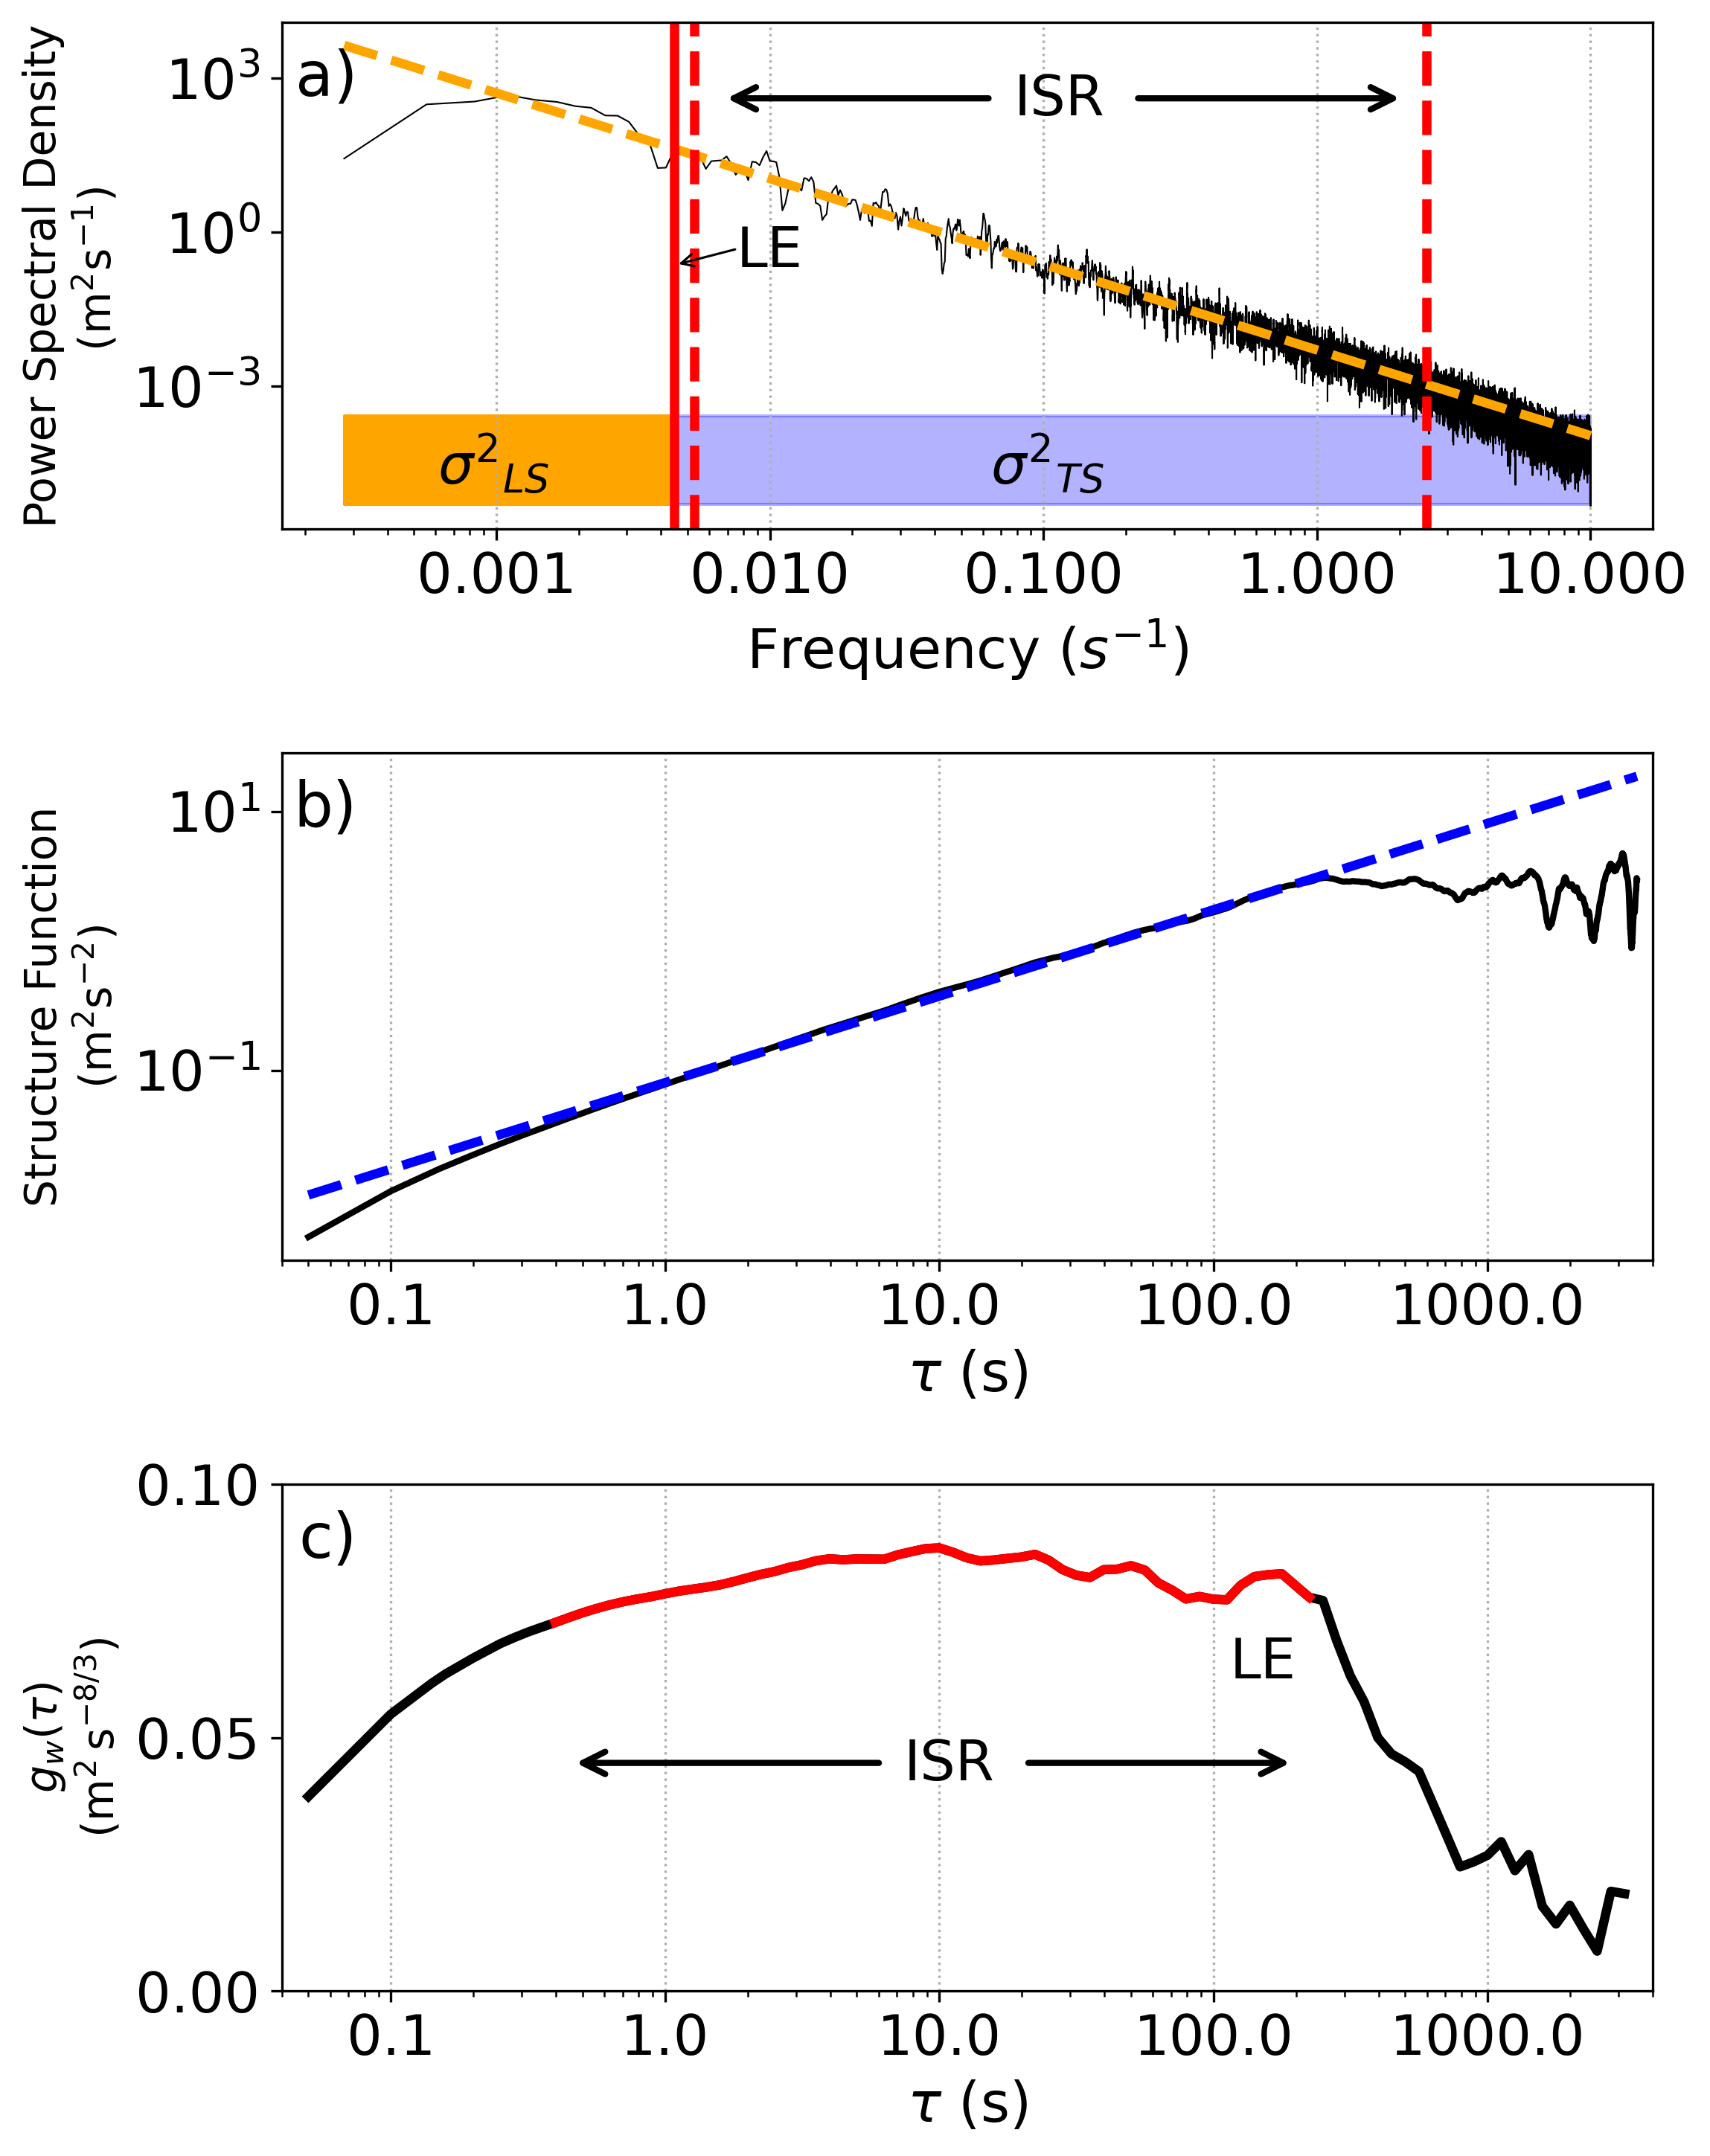

<Figure size 1920x1440 with 0 Axes>

In [3]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10))

for row in range(3):
    ax = axes[row]

    if row == 0:
        df = pd.read_fwf("C:/Users/lisad/OneDrive/Documents/bob_turb/data/figure_1/POWER_SPECTRAL_DENSITY_XPIA_20150320_SONIC_SE_w_203000_213000_STRUC_FUNC_LIM_300m.txt", header=0)

        ax.plot(df['frq,Hz'], df['pwsp,m2s-1'], color='black', linewidth=0.5)
        ax.plot(df['frq,Hz'], df['pwsp_fit,m2s-1'], color='orange', linestyle='dashed')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.3f}'))
        ax.grid(axis='x', linestyle='dotted')
        ax.set_xlabel(r'Frequency ($s^{-1}$)')
        ax.set_ylabel(r'Power Spectral Density' '\n' r' (m$^2$s$^{-1}$)', fontsize=14)
        ax.axvline(x=0.0053, linestyle='--', color='red') #min inertial subrange - 1st dashed vertical line
        ax.axvline(x=2.51787, linestyle='--', color='red') # max inertial subrange - 2nd dashed vertical line
        ax.axvline(x=0.004477, color='red') # solid line to left of the min 
        x1, x2 = 0.000278, 0.004477 # Draw purple box
        y1, y2 = 0.000005, 0.000267
        ax.fill_between([x1, x2], y1, y2, color='orange')
        x1, x2 = 0.004477, 10.0 # Draw blue box
        y1, y2 = 0.000005, 0.000267
        ax.fill_between([x1, x2], y1, y2, color='blue', alpha=0.3)
        ax.text(0.195, 0.19, '$\sigma^2$$_{LS}$', transform=ax.transAxes, ha='right', va='top', fontsize=18) #sigma labels
        ax.text(0.6, 0.19, '$\sigma^2$$_{TS}$', transform=ax.transAxes, ha='right', va='top', fontsize=18)
        ax.text(0.6, 0.9, 'ISR', transform=ax.transAxes, ha='right', va='top', fontsize=18) # ISR label & arrows
        ax.annotate('', xy=(0.32, 0.85), xytext=(0.52, 0.85), xycoords='axes fraction', textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=2, color='black')) #left pting arrow
        ax.annotate('', xy=(0.82, 0.85), xytext=(0.62, 0.85), xycoords='axes fraction', textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=2, color='black')) #right pting arrow
        ax.text(0.38, 0.6, 'LE', transform=ax.transAxes, ha='right', va='top', fontsize=18) # LE label & arrow
        ax.annotate('', xy=(0.285, 0.52), xytext=(0.335, 0.555), xycoords='axes fraction', textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=0.75, color='black', mutation_scale=10)) #small arrow pointing to dashed line
        ax.text(0.055, 0.95, 'a)', transform=ax.transAxes, ha='right', va='top', fontsize=20) # panel label
        
    elif row == 1:
        specs = [(0, 12), (13, 22), (23, 37),(38,48)]
        df = pd.read_fwf("C:/Users/lisad/OneDrive/Documents/bob_turb/data/figure_1/ORIGINAL&COMPENSATED_STRUC_FUNC_XPIA_20150320_SONIC_SE_w_203000_213000_300m.txt", header=0,colspecs=specs)
        ax.plot(df['tau,s'], df['sf,m2s-2'], color='black', linewidth=2)
        ax.plot(df['tau,s'], df['sf_fit,m2s-2'], color='blue', linestyle='dashed')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim(0.04, 4000)
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
        ax.grid(axis='x', linestyle='dotted')
        ax.set_xlabel(r'$\tau$ (s)')
        ax.set_ylabel(r'Structure Function' '\n' r'(m$^2$s$^{-2}$)', fontsize=14)
        ax.text(0.055, 0.95, 'b)', transform=ax.transAxes, ha='right', va='top', fontsize=20) # panel label

    elif row == 2:
        df = pd.read_fwf("C:/Users/lisad/OneDrive/Documents/bob_turb/data/figure_1/data_r0_c1.txt", header=0)
        df.rename(columns={'tau_log,s': 'tau', 'csf_log,m2s-8/3': 'csf'}, inplace=True)

        df2 = pd.read_fwf("C:/Users/lisad/OneDrive/Documents/bob_turb/data/figure_1/data_inert_c1.txt", header=0)
        df2_reversed = df2[::-1].reset_index(drop=True)

        min_val = df2_reversed["min,s"].iloc[0]
        max_val = df2_reversed["max,s"].iloc[0]
        
        red_plot = df[df["tau"].between(min_val, max_val)]

        ax.plot(df['tau'], df['csf'], color='black')
        ax.plot(red_plot['tau'], red_plot['csf'], color='red')

        ax.set_xscale('log')
        ax.set_xlim(0.04, 4000)
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
        ax.yaxis.set_ticks(np.arange(0.0, .12, 0.05))
        ax.grid(axis='x', linestyle='dotted')
        ax.set_xlabel(r'$\tau$ (s)')
        ax.set_ylabel(r'$g_w(\tau)$' '\n' r'$(\mathrm{m^2\,s^{-8/3}})$',fontsize=14)
        ax.text(0.52, 0.5, 'ISR', transform=ax.transAxes, ha='right', va='top', fontsize=18) # ISR label & arrows
        ax.annotate('', xy=(0.21, 0.45), xytext=(0.44, 0.45), xycoords='axes fraction', textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=2, color='black')) #left pting arrow
        ax.annotate('', xy=(0.74, 0.45), xytext=(0.54, 0.45), xycoords='axes fraction', textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=2, color='black')) #right pting arrow
        ax.text(0.74, 0.7, 'LE', transform=ax.transAxes, ha='right', va='top', fontsize=18) # LE label
        ax.text(0.055, 0.95, 'c)', transform=ax.transAxes, ha='right', va='top', fontsize=20) # panel label
        
plt.tight_layout()
plt.show()
                
plt.tight_layout()

fig.savefig(plotfile_csf, bbox_inches='tight')